#  EfficientNet B0 — Full Training Pipeline 
## Train · Validation · Test | Tunable Parameters | Full Evaluation


## Cell 1 — Install & Imports



In [1]:
import os, warnings, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f'TensorFlow : {tf.__version__}')
print(f'GPUs found : {tf.config.list_physical_devices("GPU")}')
print('OK Imports done')


TensorFlow : 2.21.0
GPUs found : []
OK Imports done


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np
from PIL import Image
import os

weak_classes = ['biscuits', 'soap', 'bread', 'yogurt', 'butter', 'oil']
target = 150

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

for cls in weak_classes:
    cls_dir = f'D:\\project deep\\resized_dataset_2\\{cls}'
    imgs = os.listdir(cls_dir)
    current = len(imgs)
    needed = target - current
    
    i = 0
    for img_name in imgs:
        if i >= needed:
            break
        img = load_img(f'{cls_dir}\\{img_name}', target_size=(224, 224))
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)
        for batch in datagen.flow(x, save_to_dir=cls_dir,
                                   save_prefix='aug', save_format='jpg'):
            i += 1
            break


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\project deep\\resized_dataset_2\\biscuits'

##  Cell 2 — CONFIGURATION 


In [3]:
DATASET_DIR = 'D:\\project deep\\resized_dataset_2'
OUTPUT_DIR  = 'D:\\project deep\\output'

IMG_SIZE = 224

VAL_SPLIT  = 0.15
TEST_SPLIT = 0.10

FREEZE_MODE  = 'last_block'
DROPOUT_RATE = 0.5
ADD_BN_HEAD  = True
FEATURE_DIM  = 1280

USE_DEEP_HEAD = True

BATCH_SIZE      = 32
EPOCHS          = 20
LEARNING_RATE   = 1e-4
LABEL_SMOOTHING = 0.1
WEIGHT_DECAY    = 1e-4
PATIENCE        = 5
MONITOR_METRIC  = 'val_accuracy'

AUG_ROTATION   = 0.08
AUG_ZOOM       = 0.20
AUG_BRIGHTNESS = 0.15
AUG_CONTRAST   = 0.15
AUG_FLIP       = 'horizontal_and_vertical'

RANDOM_SEED = 42
RUN_TAG     = 'exp01'

head_tag  = 'deephead' if USE_DEEP_HEAD else 'simplehead'
run_name  = f'effb0_sz{IMG_SIZE}_{FREEZE_MODE}_bs{BATCH_SIZE}_lr{LEARNING_RATE}_do{DROPOUT_RATE}_{head_tag}_{RUN_TAG}'
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('CONFIGURATION SUMMARY')
print('=' * 60)
print(f'  Run Name       : {run_name}')
print(f'  Image Size     : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Split          : Train/{(1-VAL_SPLIT-TEST_SPLIT)*100:.0f}% / Val/{VAL_SPLIT*100:.0f}% / Test/{TEST_SPLIT*100:.0f}%')
print(f'  Freeze Mode    : {FREEZE_MODE}')
print(f'  Head Type      : {"Deep (512->256->out)" if USE_DEEP_HEAD else "Simple (->out)"}')
print(f'  Dropout        : {DROPOUT_RATE}')
print(f'  Batch Size     : {BATCH_SIZE}')
print(f'  Epochs (max)   : {EPOCHS}')
print(f'  Learning Rate  : {LEARNING_RATE}')
print(f'  Patience       : {PATIENCE}')
print('=' * 60)


CONFIGURATION SUMMARY
  Run Name       : effb0_sz224_last_block_bs32_lr0.0001_do0.5_deephead_exp01
  Image Size     : 224x224
  Split          : Train/75% / Val/15% / Test/10%
  Freeze Mode    : last_block
  Head Type      : Deep (512->256->out)
  Dropout        : 0.5
  Batch Size     : 32
  Epochs (max)   : 20
  Learning Rate  : 0.0001
  Patience       : 5


##  Cell 3 — Dataset + Train/Val/Test Split


In [4]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp'}
records  = []

for cat_dir in sorted(Path(DATASET_DIR).iterdir()):
    if not cat_dir.is_dir():
        continue
    for img_path in cat_dir.iterdir():
        if img_path.suffix.lower() in IMG_EXTS:
            records.append({'image_path': str(img_path), 'category': cat_dir.name})

df = pd.DataFrame(records)
print(f'Total images : {len(df):,}')
print(f'Categories   : {df.category.nunique()}')

label_enc = LabelEncoder()
df['label'] = label_enc.fit_transform(df['category'])
NUM_CLASSES  = len(label_enc.classes_)

temp_df, test_df = train_test_split(
    df, test_size=TEST_SPLIT, stratify=df['label'], random_state=RANDOM_SEED
)

val_size_adj = VAL_SPLIT / (1 - TEST_SPLIT)
train_df, val_df = train_test_split(
    temp_df, test_size=val_size_adj, stratify=temp_df['label'], random_state=RANDOM_SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

total = len(df)
print('\nSPLIT SUMMARY')
print('=' * 40)
print(f'  Train      : {len(train_df):,}  ({len(train_df)/total*100:.1f}%)')
print(f'  Validation : {len(val_df):,}   ({len(val_df)/total*100:.1f}%)')
print(f'  Test       : {len(test_df):,}   ({len(test_df)/total*100:.1f}%)')
print(f'  Classes    : {NUM_CLASSES}')
print('=' * 40)

dist = pd.DataFrame({
    'Train': train_df['category'].value_counts(),
    'Val'  : val_df['category'].value_counts(),
    'Test' : test_df['category'].value_counts(),
}).fillna(0).astype(int)
print('\nDistribution per category:')
print(dist)


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\project deep\\resized_dataset_2'

##  Cell 4 — Data Augmentation Pipeline

Augmentation pipeline ready
  Flip       -> horizontal_and_vertical
  Rotation   -> +/-29 degrees
  Zoom       -> +/-20%
  Brightness -> +/-15%
  Contrast   -> +/-15%


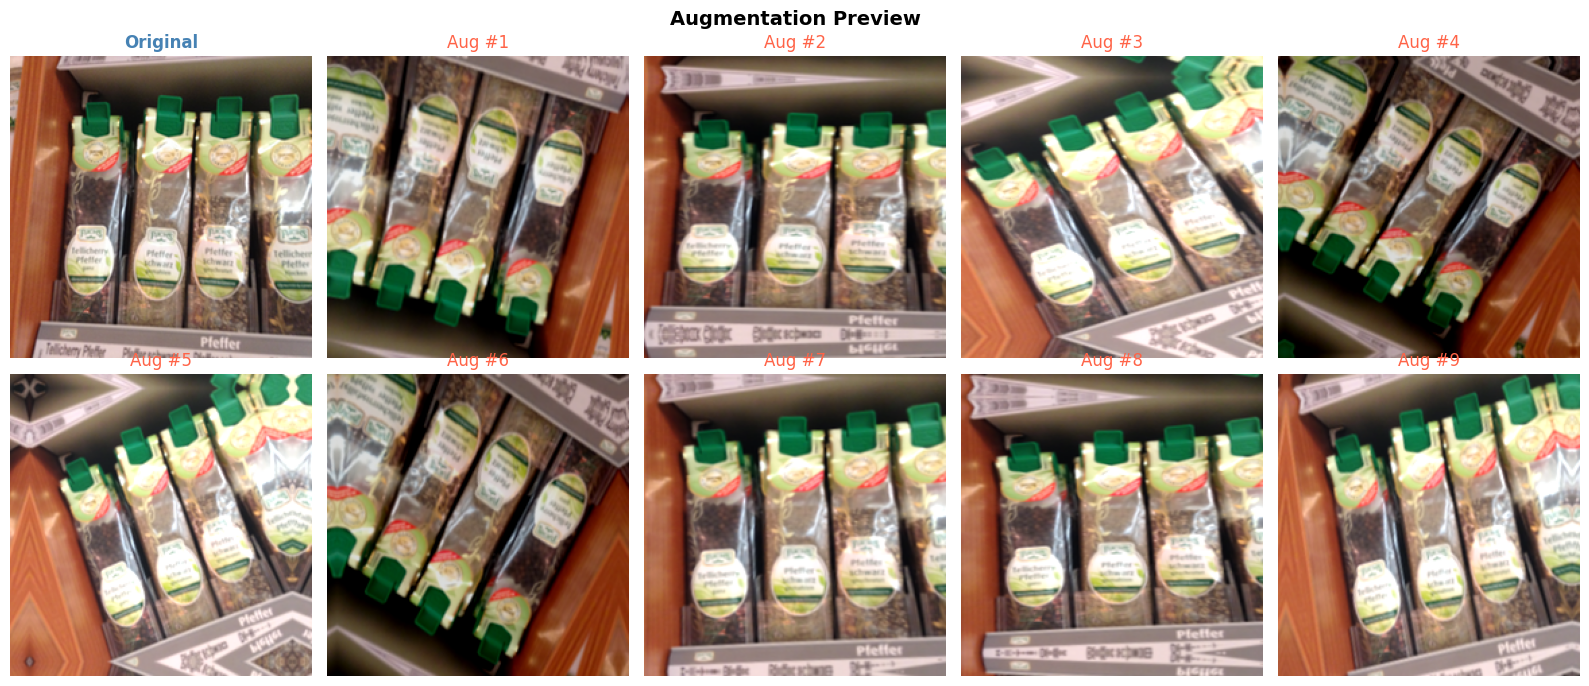

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip(mode=AUG_FLIP, seed=RANDOM_SEED),
    layers.RandomRotation(factor=AUG_ROTATION, fill_mode='reflect', seed=RANDOM_SEED),
    layers.RandomZoom(
        height_factor=(-AUG_ZOOM, AUG_ZOOM),
        width_factor=(-AUG_ZOOM, AUG_ZOOM),
        fill_mode='reflect', seed=RANDOM_SEED
    ),
    layers.RandomBrightness(factor=AUG_BRIGHTNESS, seed=RANDOM_SEED),
    layers.RandomContrast(factor=AUG_CONTRAST, seed=RANDOM_SEED),
], name='data_augmentation')

print('Augmentation pipeline ready')
print(f'  Flip       -> {AUG_FLIP}')
print(f'  Rotation   -> +/-{AUG_ROTATION*360:.0f} degrees')
print(f'  Zoom       -> +/-{AUG_ZOOM*100:.0f}%')
print(f'  Brightness -> +/-{AUG_BRIGHTNESS*100:.0f}%')
print(f'  Contrast   -> +/-{AUG_CONTRAST*100:.0f}%')

sample_path = train_df.sample(1, random_state=RANDOM_SEED)['image_path'].values[0]
img_raw = tf.io.read_file(sample_path)
img = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
img = tf.cast(img, tf.float32)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()
axes[0].imshow(img.numpy().astype('uint8'))
axes[0].set_title('Original', fontweight='bold', color='steelblue')
axes[0].axis('off')

img_batch = tf.expand_dims(img, 0)
for i in range(1, 10):
    aug = data_augmentation(img_batch, training=True)
    aug = tf.clip_by_value(aug[0], 0, 255)
    axes[i].imshow(aug.numpy().astype('uint8'))
    axes[i].set_title(f'Aug #{i}', color='tomato')
    axes[i].axis('off')

plt.suptitle('Augmentation Preview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/augmentation_preview.png', dpi=120, bbox_inches='tight')
plt.show()


## 🏗️ Cell 5A — بناء الـ Model (Simple Head — Baseline)


In [ ]:
def build_model(use_deep_head=False, freeze_mode='last_block',
                dropout_rate=0.3, num_classes=None, img_size=224, add_bn=True):
    
    inputs = layers.Input(shape=(img_size, img_size, 3), name='image_input')

    base_model = EfficientNetB0(
        include_top=False, pooling='avg',
        input_tensor=inputs, weights='imagenet'
    )

    if freeze_mode == 'all':
        base_model.trainable = False
        print('FREEZE_MODE=all -> all layers frozen (pure feature extraction)')

    elif freeze_mode == 'last_block':
        base_model.trainable = True
        LAST_BLOCK_START = 233
        for i, layer in enumerate(base_model.layers):
            layer.trainable = (i >= LAST_BLOCK_START)
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
        trainable_cnt = sum(1 for l in base_model.layers if l.trainable)
        print(f'FREEZE_MODE=last_block -> block7a open ({trainable_cnt} trainable layers in base)')

    elif freeze_mode == 'none':
        base_model.trainable = True
        for layer in base_model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
        trainable_cnt = sum(1 for l in base_model.layers if l.trainable)
        print(f'FREEZE_MODE=none -> Full fine-tuning ({trainable_cnt} trainable layers in base)')

    x = base_model.output

    if add_bn:
        x = layers.BatchNormalization(name='head_bn')(x)

    if use_deep_head:
        x = layers.Dense(512, activation='relu', name='head_dense_512')(x)
        x = layers.Dropout(dropout_rate, name='head_dropout_1')(x)
        x = layers.Dense(256, activation='relu', name='head_dense_256')(x)
        x = layers.Dropout(dropout_rate, name='head_dropout_2')(x)
        head_desc = 'Deep (1280->512->256->out)'
    else:
        x = layers.Dropout(dropout_rate, name='head_dropout')(x)
        head_desc = 'Simple (1280->out)'

    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model_name = f'effb0_{freeze_mode}_{"deep" if use_deep_head else "simple"}'
    model = models.Model(inputs, outputs, name=model_name)

    feature_extractor = models.Model(inputs, base_model.output, name='feature_extractor')

    total_p     = model.count_params()
    trainable_p = sum(tf.size(w).numpy() for w in model.trainable_weights)

    print(f'\nHead Architecture  : {head_desc}')
    print(f'Total params       : {total_p:,}')
    print(f'Trainable params   : {trainable_p:,}')
    print(f'Frozen params      : {total_p - trainable_p:,}')
    return model, feature_extractor


model, feature_extractor = build_model(
    use_deep_head = USE_DEEP_HEAD,
    freeze_mode   = FREEZE_MODE,
    dropout_rate  = DROPOUT_RATE,
    num_classes   = NUM_CLASSES,
    img_size      = IMG_SIZE,
    add_bn        = ADD_BN_HEAD
)
print('\nModel built OK')


FREEZE_MODE=last_block → block7a open (4 trainable layers in base)

Head Architecture  : Simple (1280→out)
Total params       : 4,080,311
Trainable params   : 806,420
Frozen params      : 3,273,891

Model built OK ✔


##  Cell 5B — Simple Head vs Deep Head




In [ ]:
print('Current Model Architecture Summary')
print('=' * 55)

head_layers = [l for l in model.layers if l.name.startswith('head_')]
print(f'Head type   : {"Deep" if USE_DEEP_HEAD else "Simple"}')
print(f'Head layers : {len(head_layers)}')
for l in head_layers:
    print(f'  - {l.name} ({l.__class__.__name__})')

print('\nFull layer count breakdown:')
base_layers    = [l for l in model.layers if not l.name.startswith('head_') and l.name != 'predictions']
output_layers  = [l for l in model.layers if l.name == 'predictions']
print(f'  Base (EfficientNetB0) : {len(base_layers)} layers')
print(f'  Head                  : {len(head_layers)} layers')
print(f'  Output (Dense)        : {len(output_layers)} layer')
print(f'  TOTAL                 : {len(model.layers)} layers')

total_p     = model.count_params()
trainable_p = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'\nTotal params     : {total_p:,}')
print(f'Trainable params : {trainable_p:,}  ({trainable_p/total_p*100:.1f}%)')
print(f'Frozen params    : {total_p - trainable_p:,}  ({(total_p-trainable_p)/total_p*100:.1f}%)')


Current Model Architecture Summary
Head type   : Simple
Head layers : 2
  - head_bn (BatchNormalization)
  - head_dropout (Dropout)

Full layer count breakdown:
  Base (EfficientNetB0) : 239 layers
  Head                  : 2 layers
  Output (Dense)        : 1 layer
  TOTAL                 : 242 layers

Total params     : 4,080,311
Trainable params : 806,420  (19.8%)
Frozen params    : 3,273,891  (80.2%)


## Cell 6 — Training Loop

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image_and_label(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    lbl = tf.one_hot(label, NUM_CLASSES)
    return img, lbl

def augment_fn(image, label):
    image = tf.expand_dims(image, 0)
    image = data_augmentation(image, training=True)
    image = tf.squeeze(image, 0)
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, label

def preprocess_fn(image, label):
    image = preprocess_input(image)
    return image, label

def make_dataset(df_split, augment=False, shuffle=False):
    paths  = tf.constant(df_split['image_path'].values)
    labels = tf.constant(df_split['label'].values)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(df_split), seed=RANDOM_SEED)
    ds = ds.map(load_image_and_label, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.map(preprocess_fn, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, augment=(FREEZE_MODE != 'all'), shuffle=True)
val_ds   = make_dataset(val_df,   augment=False)
test_ds  = make_dataset(test_df,  augment=False)

print(f'Train batches : {len(train_ds)}')
print(f'Val batches   : {len(val_ds)}')
print(f'Test batches  : {len(test_ds)}')

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY, clipnorm=1.0
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)

ckpt_path = f'{OUTPUT_DIR}/best_{run_name}.keras'
log_path  = f'{OUTPUT_DIR}/{run_name}_training_log.csv'

cbs = [
    callbacks.ModelCheckpoint(
        filepath=ckpt_path, monitor=MONITOR_METRIC,
        save_best_only=True, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor=MONITOR_METRIC, patience=PATIENCE,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor=MONITOR_METRIC, factor=0.5, patience=3,
        min_lr=1e-7, verbose=1
    ),
    callbacks.CSVLogger(log_path, append=False),
]

if FREEZE_MODE == 'all':
    print('FREEZE_MODE=all -> skipping training, go to Cell 9')
    history = None
else:
    print(f'Starting Training... max epochs={EPOCHS}')
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=cbs,
        verbose=1
    )
    best_val = max(history.history[MONITOR_METRIC])
    best_ep  = history.history[MONITOR_METRIC].index(best_val) + 1
    print(f'Best {MONITOR_METRIC}: {best_val:.4f} (epoch {best_ep})')


Train batches : 87
Val batches   : 18
Test batches  : 12
Starting Training... max epochs=20
Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.1208 - loss: 3.6602
Epoch 1: val_accuracy improved from None to 0.39531, saving model to D:\project deep\output/best_effb0_sz224_last_block_bs32_lr0.0001_do0.3_simplehead_exp01.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 92s 960ms/step - accuracy: 0.1748 - loss: 3.2753 - val_accuracy: 0.3953 - val_loss: 2.3242 - learning_rate: 1.0000e-04
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 877ms/step - accuracy: 0.3526 - loss: 2.4632
Epoch 2: val_accuracy improved from 0.39531 to 0.55415, saving model to D:\project deep\output/best_effb0_sz224_last_block_bs32_lr0.0001_do0.3_simplehead_exp01.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.3882 - loss: 2.3730 - val_accuracy: 0.5542 - val_loss: 1.8701 - learning_rate: 1.0000e-04
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4625 - loss: 2.1535
Epoch 3: val_accuracy improved from

##  Cell 7 — Validation Evaluation


Evaluating on Validation Set...
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 952ms/step

VALIDATION RESULTS
  Accuracy    : 0.7960  (79.60%)
  F1-Macro    : 0.7680
  F1-Weighted : 0.7929
              precision    recall  f1-score   support

    biscuits       0.67      0.50      0.57         8
       bread       0.85      0.92      0.88        12
      butter       0.67      0.43      0.52        14
      cheese       0.67      0.57      0.62        21
       chips       0.72      0.78      0.75        36
   chocolate       0.90      0.79      0.84        48
       flour       0.76      0.54      0.63        24
       honey       0.82      0.89      0.85        35
         jam       0.87      0.89      0.88        44
       juice       0.80      0.89      0.85        46
        milk       0.80      0.77      0.79        31
        nuts       0.75      0.90      0.82        30
         oil       0.86      0.82      0.84        22
       pasta       0.85      0.88      0.87        33
        rice    

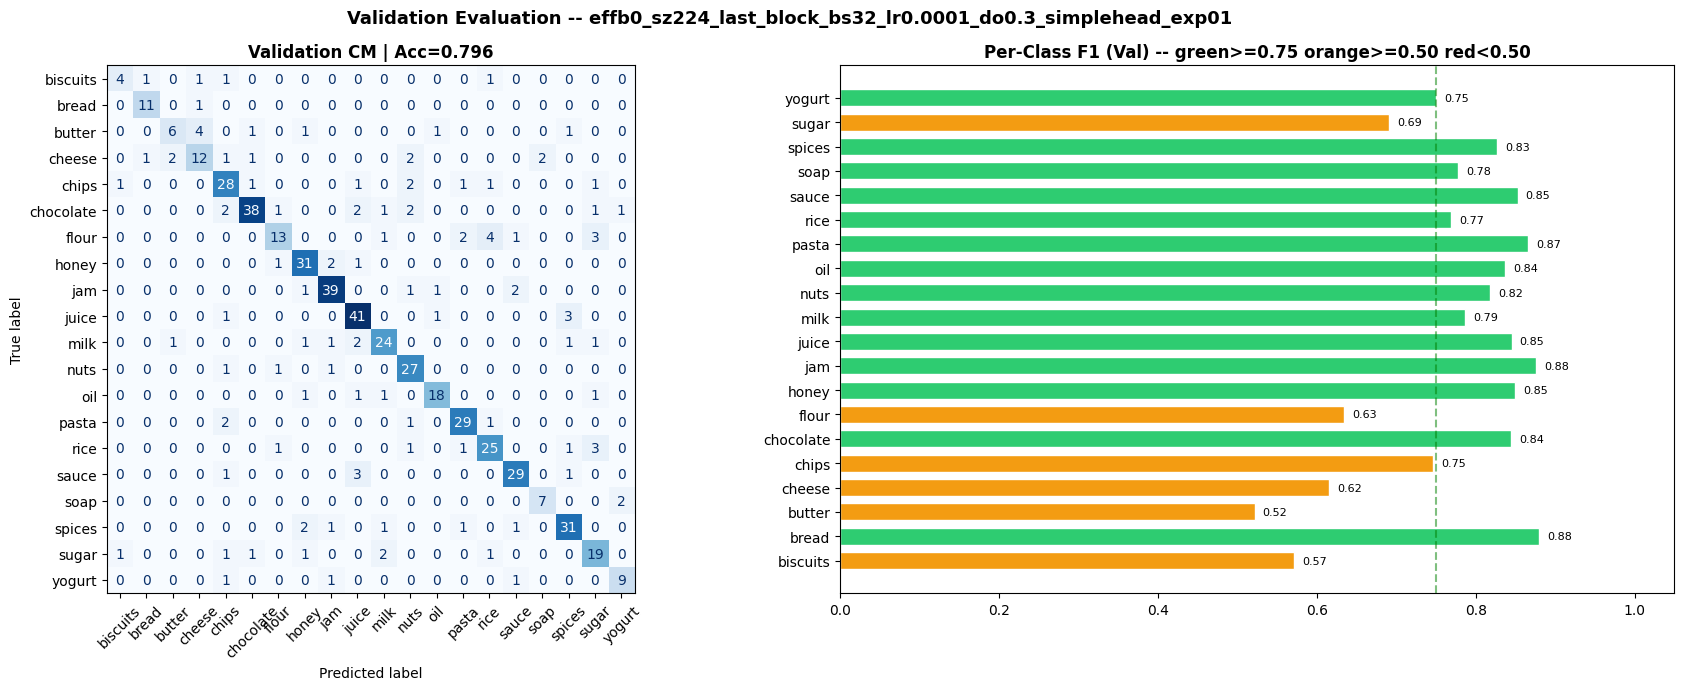

In [ ]:
print('Evaluating on Validation Set...')
val_pred_probs = model.predict(val_ds, verbose=1)
val_pred = np.argmax(val_pred_probs, axis=1)
val_true = val_df['label'].values
class_names = label_enc.classes_

val_acc = accuracy_score(val_true, val_pred)
val_f1m = f1_score(val_true, val_pred, average='macro')
val_f1w = f1_score(val_true, val_pred, average='weighted')

print('\nVALIDATION RESULTS')
print('=' * 45)
print(f'  Accuracy    : {val_acc:.4f}  ({val_acc*100:.2f}%)')
print(f'  F1-Macro    : {val_f1m:.4f}')
print(f'  F1-Weighted : {val_f1w:.4f}')
print('=' * 45)
print(classification_report(val_true, val_pred, target_names=class_names))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
cm = confusion_matrix(val_true, val_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], xticks_rotation=45, colorbar=False, cmap='Blues', values_format='d'
)
axes[0].set_title(f'Validation CM | Acc={val_acc:.3f}', fontweight='bold')

f1_pc  = f1_score(val_true, val_pred, average=None)
colors = ['#2ecc71' if v >= 0.75 else '#f39c12' if v >= 0.5 else '#e74c3c' for v in f1_pc]
bars   = axes[1].barh(class_names, f1_pc, color=colors, edgecolor='white', height=0.7)
axes[1].set_xlim([0, 1.05])
axes[1].axvline(0.75, color='green', linestyle='--', alpha=0.5)
axes[1].set_title('Per-Class F1 (Val) -- green>=0.75 orange>=0.50 red<0.50', fontweight='bold')
for bar, val in zip(bars, f1_pc):
    axes[1].text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)

plt.suptitle(f'Validation Evaluation -- {run_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/{run_name}_val_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


##  Cell 8 — TEST SET Evaluation 


FINAL TEST SET EVALUATION
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 657ms/step

TEST RESULTS
  Accuracy    : 0.8108  (81.08%)
  F1-Macro    : 0.7984
  F1-Weighted : 0.8093

Overfitting Check:
  Best Val Acc : 0.7960
  Test Acc     : 0.8108
  Gap          : -0.0148  GREAT -- no overfitting

Per-Class Test Report:
              precision    recall  f1-score   support

    biscuits       0.60      0.60      0.60         5
       bread       0.89      1.00      0.94         8
      butter       0.71      0.56      0.62         9
      cheese       0.75      0.64      0.69        14
       chips       0.71      0.92      0.80        24
   chocolate       0.87      0.84      0.86        32
       flour       0.73      0.69      0.71        16
       honey       0.95      0.91      0.93        23
         jam       0.84      0.90      0.87        29
       juice       0.91      0.97      0.94        31
        milk       0.81      0.81      0.81        21
        nuts       0.77      0.85      0.81      

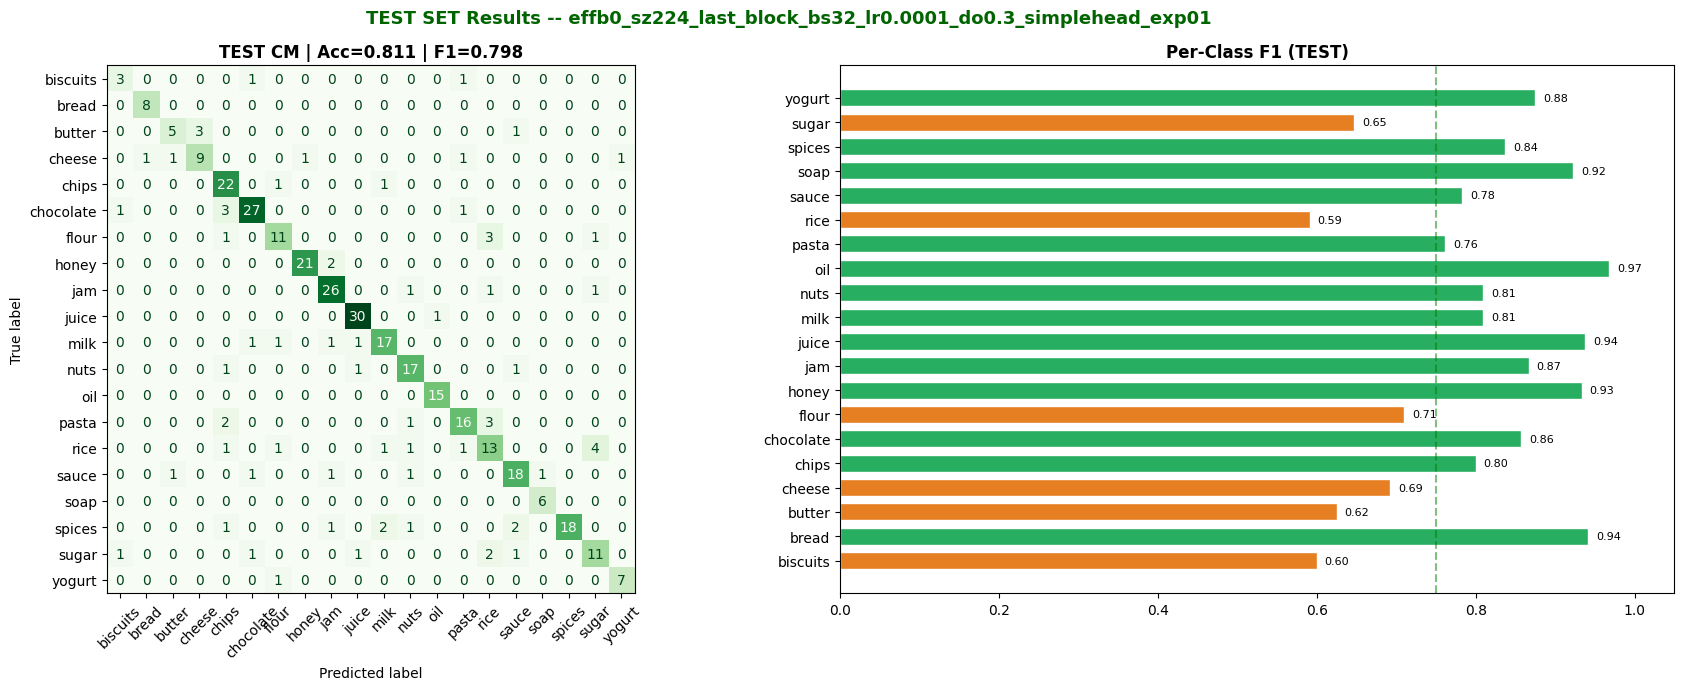

Test metrics saved -> D:\project deep\output/effb0_sz224_last_block_bs32_lr0.0001_do0.3_simplehead_exp01_metrics.csv


In [ ]:
print('FINAL TEST SET EVALUATION')
print('WARNING: run this cell only ONCE at the end!')
print('=' * 55)

test_pred_probs = model.predict(test_ds, verbose=1)
test_pred = np.argmax(test_pred_probs, axis=1)
test_true = test_df['label'].values

test_acc = accuracy_score(test_true, test_pred)
test_f1m = f1_score(test_true, test_pred, average='macro')
test_f1w = f1_score(test_true, test_pred, average='weighted')

print('\nTEST RESULTS')
print('=' * 55)
print(f'  Accuracy    : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  F1-Macro    : {test_f1m:.4f}')
print(f'  F1-Weighted : {test_f1w:.4f}')
print('=' * 55)

if history:
    best_val = max(history.history['val_accuracy'])
    gap = best_val - test_acc
    print(f'\nOverfitting Check:')
    print(f'  Best Val Acc : {best_val:.4f}')
    print(f'  Test Acc     : {test_acc:.4f}')
    print(f'  Gap          : {gap:.4f}', end='  ')
    if abs(gap) < 0.03:
        print('GREAT -- no overfitting')
    elif gap > 0.05:
        print('WARNING -- overfitting, increase dropout or augmentation')
    else:
        print('ACCEPTABLE')

print('\nPer-Class Test Report:')
print(classification_report(test_true, test_pred, target_names=class_names))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
cm_test = confusion_matrix(test_true, test_pred)
ConfusionMatrixDisplay(cm_test, display_labels=class_names).plot(
    ax=axes[0], xticks_rotation=45, colorbar=False, cmap='Greens', values_format='d'
)
axes[0].set_title(f'TEST CM | Acc={test_acc:.3f} | F1={test_f1m:.3f}', fontweight='bold')

f1_tc  = f1_score(test_true, test_pred, average=None)
ct = ['#27ae60' if v >= 0.75 else '#e67e22' if v >= 0.5 else '#c0392b' for v in f1_tc]
bt = axes[1].barh(class_names, f1_tc, color=ct, edgecolor='white', height=0.7)
axes[1].set_xlim([0, 1.05])
axes[1].axvline(0.75, color='green', linestyle='--', alpha=0.5)
axes[1].set_title('Per-Class F1 (TEST)', fontweight='bold')
for bar, val in zip(bt, f1_tc):
    axes[1].text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)

plt.suptitle(f'TEST SET Results -- {run_name}', fontsize=13, fontweight='bold', color='darkgreen')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/{run_name}_test_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

metrics_df = pd.DataFrame([{
    'run_name'        : run_name,
    'img_size'        : IMG_SIZE,
    'freeze_mode'     : FREEZE_MODE,
    'batch_size'      : BATCH_SIZE,
    'learning_rate'   : LEARNING_RATE,
    'dropout'         : DROPOUT_RATE,
    'val_acc'         : round(max(history.history['val_accuracy']) if history else 0, 4),
    'test_acc'        : round(test_acc, 4),
    'test_f1_macro'   : round(test_f1m, 4),
    'test_f1_weighted': round(test_f1w, 4),
}])
metrics_path = f'{OUTPUT_DIR}/{run_name}_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f'Test metrics saved -> {metrics_path}')


##  Cell 8b — Training vs Validation Curves

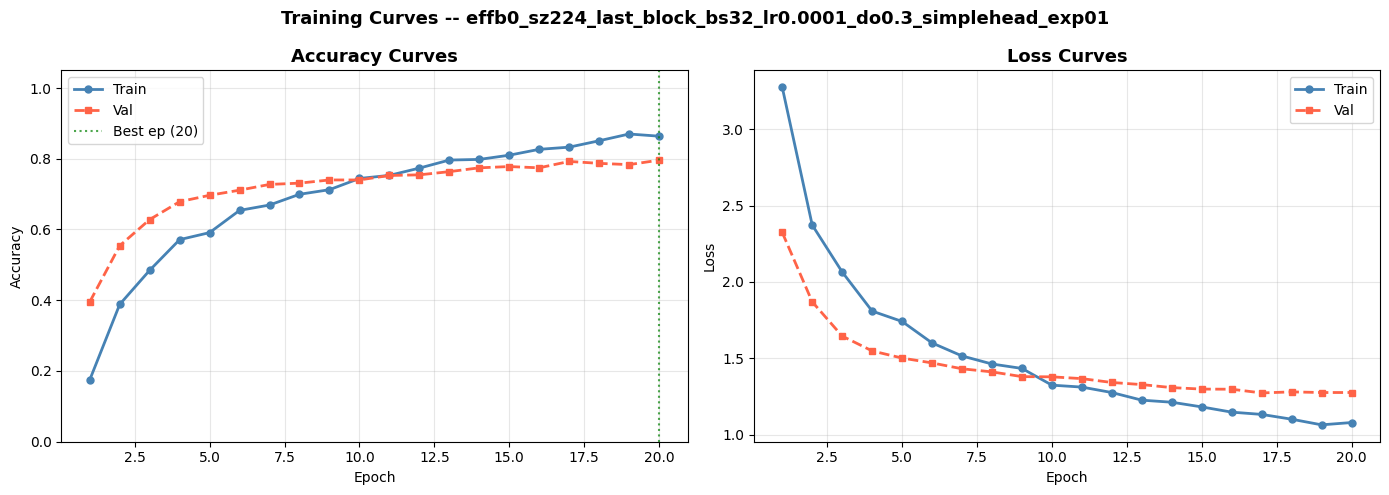

In [ ]:
if history is not None:
    hist = history.history
    epochs_ran = range(1, len(hist['accuracy']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_ran, hist['accuracy'],     'o-', color='steelblue', label='Train', lw=2, ms=5)
    axes[0].plot(epochs_ran, hist['val_accuracy'], 's--', color='tomato',   label='Val',   lw=2, ms=5)
    best_ep = hist['val_accuracy'].index(max(hist['val_accuracy'])) + 1
    axes[0].axvline(best_ep, color='green', linestyle=':', alpha=0.7, label=f'Best ep ({best_ep})')
    axes[0].set_title('Accuracy Curves', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim([0, 1.05])

    axes[1].plot(epochs_ran, hist['loss'],     'o-', color='steelblue', label='Train', lw=2, ms=5)
    axes[1].plot(epochs_ran, hist['val_loss'], 's--', color='tomato',   label='Val',   lw=2, ms=5)
    axes[1].set_title('Loss Curves', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Training Curves -- {run_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{run_name}_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No history -- FREEZE_MODE=all, no training was done')


##  Cell 9 — Feature Extraction +  Saving Outputs


In [ ]:
print(f'Extracting features from {len(df):,} images...')

def make_extraction_ds(paths_list):
    def load_img(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = tf.cast(img, tf.float32)
        return preprocess_input(img)
    ds = tf.data.Dataset.from_tensor_slices(paths_list)
    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

all_paths    = df['image_path'].values.tolist()
all_features = feature_extractor.predict(make_extraction_ds(all_paths), verbose=1)

print(f'Features shape : {all_features.shape}')
print(f'Memory         : {all_features.nbytes / 1e6:.2f} MB')

train_paths = set(train_df['image_path'])
val_paths   = set(val_df['image_path'])
test_paths  = set(test_df['image_path'])

split_labels = [
    'train' if p in train_paths else 'val' if p in val_paths else 'test' if p in test_paths else 'unknown'
    for p in all_paths
]
unknown_count = sum(sp == 'unknown' for sp in split_labels)
if unknown_count > 0:
    print(f'WARNING: {unknown_count} samples not matched to any split')

npz_path = f'{OUTPUT_DIR}/{run_name}_features.npz'
np.savez_compressed(
    npz_path,
    features   = all_features,
    image_paths= np.asarray(all_paths, dtype=str),
    labels     = np.asarray(df['label'].values, dtype=np.int32),
    categories = np.asarray(df['category'].astype(str).values, dtype=str),
    split      = np.asarray(split_labels, dtype=str)
)
print(f'Features saved  -> {npz_path}')

enc_path = f'{OUTPUT_DIR}/label_encoder.pkl'
with open(enc_path, 'wb') as f:
    pickle.dump(label_enc, f)
print(f'Label encoder   -> {enc_path}')

feature_extractor.save(f'{OUTPUT_DIR}/{run_name}_extractor.keras')
model.save(f'{OUTPUT_DIR}/{run_name}_full_model.keras')
print(f'Models saved    -> {OUTPUT_DIR}/')


Extracting features from 3,693 images...
116/116 ━━━━━━━━━━━━━━━━━━━━ 87s 706ms/step
Features shape : (3693, 1280)
Memory         : 18.91 MB
Features saved  -> D:\project deep\output/effb0_sz224_last_block_bs32_lr0.0001_do0.3_simplehead_exp01_features.npz
Label encoder   -> D:\project deep\output/label_encoder.pkl
Models saved    -> D:\project deep\output/


##  Cell 10 — t-SNE + PCA Visualization



Loaded: (3693, 1280) | NaN: 0


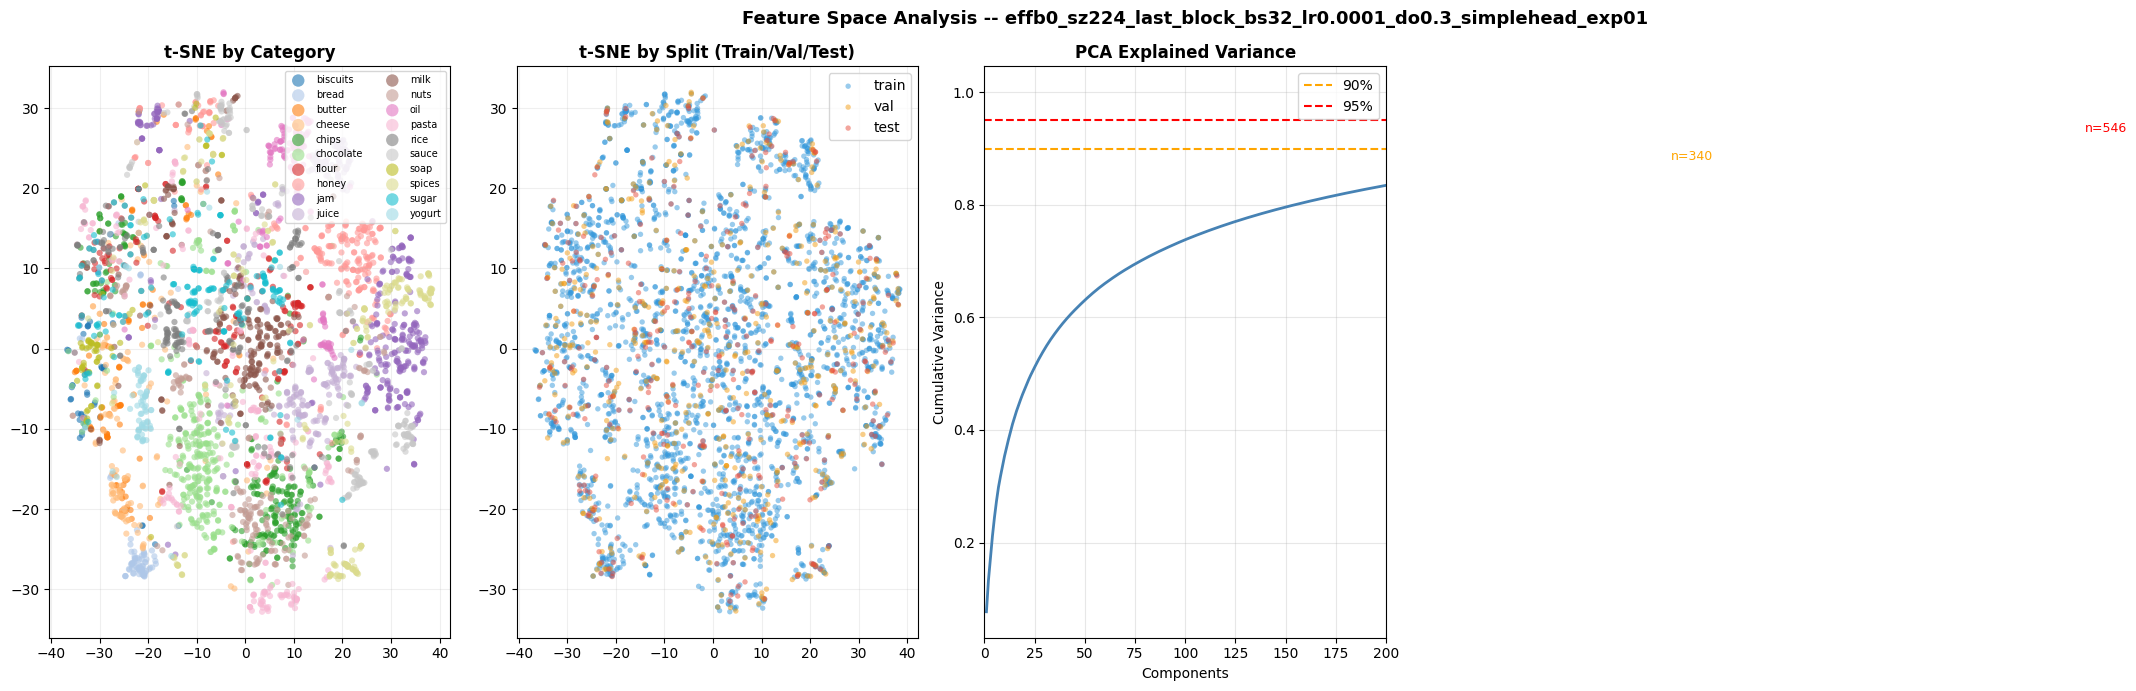

Visualization saved


In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import inspect

loaded = np.load(npz_path, allow_pickle=True)
feats  = loaded['features']
cats   = loaded['categories']
splits = loaded['split']

print(f'Loaded: {feats.shape} | NaN: {np.isnan(feats).sum()}')

pca50   = PCA(n_components=50, random_state=RANDOM_SEED)
feats50 = pca50.fit_transform(feats)

tsne_kw = dict(n_components=2, perplexity=30, random_state=RANDOM_SEED)
if 'max_iter' in inspect.signature(TSNE).parameters:
    tsne_kw['max_iter'] = 500
else:
    tsne_kw['n_iter'] = 500
feats2 = TSNE(**tsne_kw).fit_transform(feats50)

unique_cats  = sorted(set(cats))
colors       = plt.cm.tab20(np.linspace(0, 1, len(unique_cats)))
cat_to_color = {c: colors[i] for i, c in enumerate(unique_cats)}

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for cat in unique_cats:
    mask = cats == cat
    axes[0].scatter(feats2[mask,0], feats2[mask,1], c=[cat_to_color[cat]],
                    label=cat, alpha=0.6, s=20, edgecolors='none')
axes[0].set_title('t-SNE by Category', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=7, markerscale=2, ncol=2)
axes[0].grid(True, alpha=0.2)

split_colors = {'train': '#3498db', 'val': '#f39c12', 'test': '#e74c3c'}
for sp, sc in split_colors.items():
    mask = splits == sp
    axes[1].scatter(feats2[mask,0], feats2[mask,1], c=sc,
                    label=sp, alpha=0.5, s=15, edgecolors='none')
axes[1].set_title('t-SNE by Split (Train/Val/Test)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.2)

full_pca  = PCA(random_state=RANDOM_SEED).fit(feats)
explained = np.cumsum(full_pca.explained_variance_ratio_)
axes[2].plot(range(1, len(explained)+1), explained, color='steelblue', lw=2)
axes[2].axhline(0.90, color='orange', linestyle='--', label='90%')
axes[2].axhline(0.95, color='red',    linestyle='--', label='95%')
n90 = np.argmax(explained >= 0.90) + 1
n95 = np.argmax(explained >= 0.95) + 1
axes[2].text(n90+2, 0.88, f'n={n90}', color='orange', fontsize=9)
axes[2].text(n95+2, 0.93, f'n={n95}', color='red',    fontsize=9)
axes[2].set_title('PCA Explained Variance', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Components'); axes[2].set_ylabel('Cumulative Variance')
axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].set_xlim([0, min(200, len(explained))])

plt.suptitle(f'Feature Space Analysis -- {run_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/{run_name}_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization saved')


##  Cell 11 — Multi-Experiment Comparison


In [ ]:
import glob

metrics_files = sorted(glob.glob(f'{OUTPUT_DIR}/*_metrics.csv'))
print(f'Found {len(metrics_files)} experiment(s)')

if len(metrics_files) == 0:
    print('No experiments found -- run Cell 8 first')
else:
    all_m = pd.concat([pd.read_csv(f) for f in metrics_files], ignore_index=True)
    all_m = all_m.sort_values('test_acc', ascending=False)

    print('\nEXPERIMENT COMPARISON (sorted by Test Accuracy)')
    print('=' * 80)
    cols = ['run_name', 'freeze_mode', 'img_size', 'learning_rate', 'dropout',
            'val_acc', 'test_acc', 'test_f1_macro']
    print(all_m[cols].to_string(index=False))
    print('=' * 80)

    best = all_m.iloc[0]
    print(f'\nBest Run : {best["run_name"]}')
    print(f'Test Acc : {best["test_acc"]:.4f}')
    print(f'F1-Macro : {best["test_f1_macro"]:.4f}')

    if len(all_m) > 1:
        fig, ax = plt.subplots(figsize=(max(8, len(all_m)*2), 5))
        x = range(len(all_m))
        ax.bar(x, all_m['test_acc'], color='steelblue', label='Test Acc', alpha=0.8)
        ax.bar(x, all_m['val_acc'],  color='orange',    label='Val Acc',  alpha=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels([n[:25] for n in all_m['run_name']], rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Accuracy'); ax.set_ylim([0, 1])
        ax.legend(); ax.grid(axis='y', alpha=0.3)
        ax.set_title('Experiment Comparison', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/comparison_report.png', dpi=150, bbox_inches='tight')
        plt.show()

    all_m.to_csv(f'{OUTPUT_DIR}/comparison_report.csv', index=False)
    print('Comparison report saved')


Found 1 experiment(s)

EXPERIMENT COMPARISON (sorted by Test Accuracy)
                                                   run_name freeze_mode  img_size  learning_rate  dropout  val_acc  test_acc  test_f1_macro
effb0_sz224_last_block_bs32_lr0.0001_do0.3_simplehead_exp01  last_block       224         0.0001      0.3    0.796    0.8108         0.7984

Best Run : effb0_sz224_last_block_bs32_lr0.0001_do0.3_simplehead_exp01
Test Acc : 0.8108
F1-Macro : 0.7984
Comparison report saved


## Cell 12 — Prediction on new photo i have been download it from websit


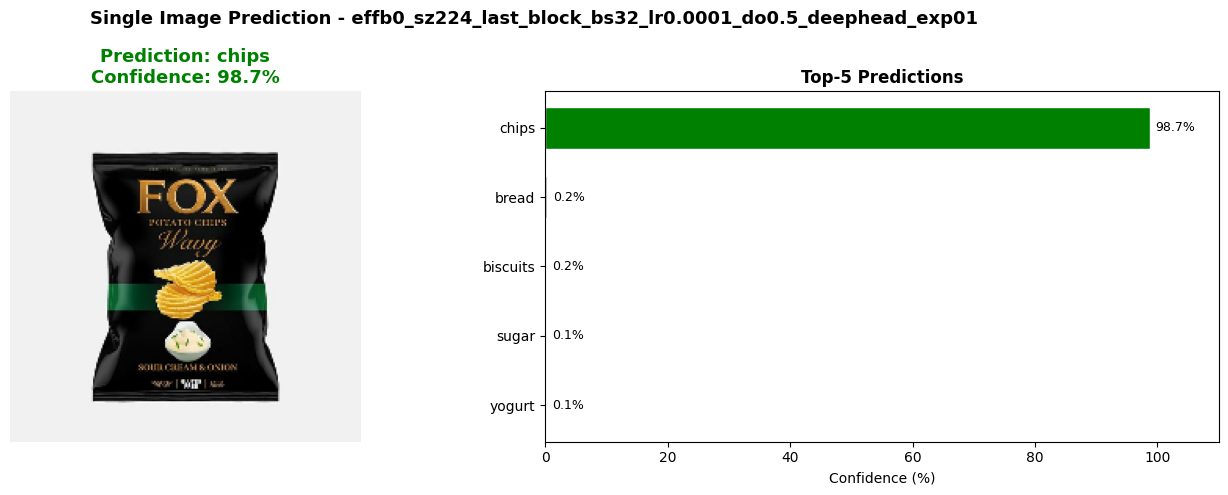


PREDICTION RESULTS
  Image        : C:\Users\M2h\Desktop\m.jpg
  Predicted    : chips
  Confidence   : 98.72%

  Top-K Breakdown:
    chips                #############################  98.72%
    bread                                               0.20%
    biscuits                                            0.15%
    sugar                                               0.15%
    yogurt                                              0.12%


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

NEW_IMAGE_PATH = 'C:\\Users\\M2h\\Desktop\\m.jpg'

def predict_single_image(image_path, model, label_encoder, img_size=224, top_k=5):
    
    if not os.path.exists(image_path):
        raise FileNotFoundError(f'Image file not found: {image_path}')

    raw = tf.io.read_file(image_path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, [img_size, img_size])
    img_display = tf.cast(img, tf.uint8).numpy()

    img_processed = tf.cast(img, tf.float32)
    img_processed = preprocess_input(img_processed)
    img_batch     = tf.expand_dims(img_processed, 0)

    probs      = model.predict(img_batch, verbose=0)[0]
    top_k_idx  = np.argsort(probs)[::-1][:top_k]
    top_k_probs = probs[top_k_idx]
    top_k_names = label_encoder.classes_[top_k_idx]

    pred_class = top_k_names[0]
    pred_conf  = top_k_probs[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].imshow(img_display)
    axes[0].axis('off')
    conf_color = 'green' if pred_conf >= 0.75 else 'orange' if pred_conf >= 0.50 else 'red'
    axes[0].set_title(
        f'Prediction: {pred_class}\nConfidence: {pred_conf*100:.1f}%',
        fontsize=13, fontweight='bold', color=conf_color
    )

    bar_colors = [conf_color if i == 0 else '#95a5a6' for i in range(top_k)]
    bars = axes[1].barh(
        range(top_k), top_k_probs[::-1] * 100,
        color=bar_colors[::-1], edgecolor='white', height=0.6
    )
    axes[1].set_yticks(range(top_k))
    axes[1].set_yticklabels(top_k_names[::-1], fontsize=10)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_xlim([0, 110])
    axes[1].set_title(f'Top-{top_k} Predictions', fontsize=12, fontweight='bold')
    for bar, val in zip(bars, top_k_probs[::-1] * 100):
        axes[1].text(val + 1, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)

    plt.suptitle(f'Single Image Prediction - {run_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{run_name}_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nPREDICTION RESULTS')
    print('=' * 45)
    print(f'  Image        : {image_path}')
    print(f'  Predicted    : {pred_class}')
    print(f'  Confidence   : {pred_conf*100:.2f}%')
    if pred_conf < 0.50:
        print('  LOW confidence - model not confident')
        print('  Image may be different from training data')
    print('\n  Top-K Breakdown:')
    for name, prob in zip(top_k_names, top_k_probs):
        bar_fill = '#' * int(prob * 30)
        print(f'    {name:20s} {bar_fill:30s} {prob*100:.2f}%')
    print('=' * 45)

    return pred_class, pred_conf, dict(zip(top_k_names, top_k_probs))


if not os.path.exists(NEW_IMAGE_PATH):
    fallback_path = test_df.sample(1, random_state=RANDOM_SEED)['image_path'].values[0]
    print(f'WARNING: image not found -> {NEW_IMAGE_PATH}')
    print(f'Using a sample from test set instead -> {fallback_path}')
    NEW_IMAGE_PATH = fallback_path

pred_class, pred_conf, all_probs = predict_single_image(
    image_path    = NEW_IMAGE_PATH,
    model         = model,
    label_encoder = label_enc,
    img_size      = IMG_SIZE,
    top_k         = min(5, NUM_CLASSES)
)


##  Cell 13 — Top-K Similar Products (Image-Based Recommendation)


Loading saved features...
Features loaded: (3693, 1280)
Total images   : 3693
Query image: D:\project deep\resized_dataset\nuts\NUTS0010.png

TOP-K SIMILAR PRODUCTS
  Query: D:\project deep\resized_dataset\nuts\NUTS0010.png
  Rank  Category             Similarity      Price
-----------------------------------------------------------------
  #1    nuts                     0.6202        N/A
  #2    nuts                     0.6033        N/A
  #3    nuts                     0.5993        N/A
  #4    nuts                     0.5831        N/A
  #5    nuts                     0.5787        N/A


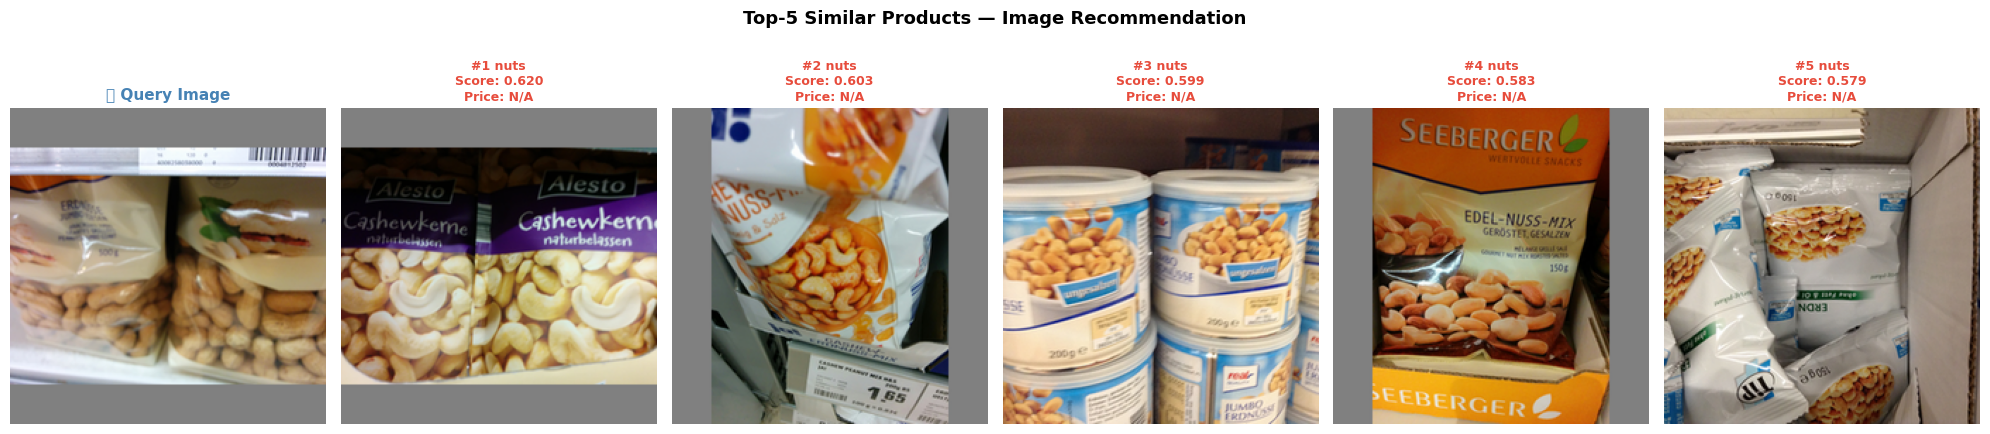

Saved → D:\project deep\output/effb0_sz224_last_block_bs32_lr0.0001_do0.3_simplehead_exp01_topk_recommendation.png


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

print('Loading saved features...')
loaded      = np.load(npz_path, allow_pickle=True)
all_feats   = loaded['features']
all_paths   = loaded['image_paths']
all_cats    = loaded['categories']
all_labels  = loaded['labels']
all_splits  = loaded['split']

print(f'Features loaded: {all_feats.shape}')
print(f'Total images   : {len(all_paths)}')

path_to_price = {}

def get_image_price(img_path):
    return path_to_price.get(str(img_path), 'N/A')


def find_top_k_similar(query_path, all_features, all_image_paths,
                        all_categories, top_k=5, same_split_only=False):
    
    query_path_str = str(query_path)
    all_paths_str  = [str(p) for p in all_image_paths]

    if query_path_str in all_paths_str:
        q_idx         = all_paths_str.index(query_path_str)
        query_feature = all_features[q_idx:q_idx+1]
    else:
        print('Query not in dataset - extracting feature on-the-fly...')
        img = tf.io.read_file(query_path_str)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = tf.cast(img, tf.float32)
        img = preprocess_input(img)
        img = tf.expand_dims(img, 0)
        query_feature = feature_extractor.predict(img, verbose=0)
        q_idx = -1

    similarities = cos_sim(query_feature, all_features)[0]

    sorted_idx = np.argsort(similarities)[::-1]
    sorted_idx = [i for i in sorted_idx if i != q_idx][:top_k]

    results = []
    for rank, idx in enumerate(sorted_idx, 1):
        results.append({
            'rank'       : rank,
            'path'       : str(all_image_paths[idx]),
            'category'   : str(all_categories[idx]),
            'similarity' : float(similarities[idx]),
            'price'      : get_image_price(all_image_paths[idx]),
        })

    return results


def display_top_k_results(query_path, results, figsize=(20, 5)):
    
    n_cols = len(results) + 1
    fig, axes = plt.subplots(1, n_cols, figsize=figsize)

    try:
        q_img = mpimg.imread(query_path)
        axes[0].imshow(q_img)
    except Exception:
        axes[0].text(0.5, 0.5, 'Image\nNot Found', ha='center', va='center',
                     fontsize=10, color='red')
    axes[0].set_title('Query Image', fontsize=11, fontweight='bold', color='steelblue')
    axes[0].axis('off')

    for i, res in enumerate(results):
        ax = axes[i + 1]
        try:
            r_img = mpimg.imread(res['path'])
            ax.imshow(r_img)
        except Exception:
            ax.text(0.5, 0.5, 'Image\nNot Found', ha='center', va='center',
                    fontsize=9, color='gray')

        score_color = ('#27ae60' if res['similarity'] >= 0.85
                       else '#e67e22' if res['similarity'] >= 0.70
                       else '#e74c3c')

        title = (f"#{res['rank']} {res['category']}\n"
                 f"Score: {res['similarity']:.3f}\n"
                 f"Price: {res['price']}")
        ax.set_title(title, fontsize=9, color=score_color, fontweight='bold')
        ax.axis('off')

    plt.suptitle(f'Top-{len(results)} Similar Products - Image Recommendation',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    out_path = f'{OUTPUT_DIR}/{run_name}_topk_recommendation.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out_path}')


def print_recommendation_table(query_path, results):
    
    print('\nTOP-K SIMILAR PRODUCTS')
    print('=' * 65)
    print(f'  Query: {query_path}')
    print('=' * 65)
    print(f'  {"Rank":<5} {"Category":<20} {"Similarity":>10} {"Price":>10}')
    print('-' * 65)
    for r in results:
        price_str = str(r['price']) if r['price'] != 'N/A' else 'N/A'
        print(f"  #{r['rank']:<4} {r['category']:<20} {r['similarity']:>10.4f} {price_str:>10}")
    print('=' * 65)


TOP_K       = 5
query_path  = test_df.sample(1, random_state=7)['image_path'].values[0]

print(f'Query image: {query_path}')
results = find_top_k_similar(
    query_path      = query_path,
    all_features    = all_feats,
    all_image_paths = all_paths,
    all_categories  = all_cats,
    top_k           = TOP_K
)

print_recommendation_table(query_path, results)
display_top_k_results(query_path, results)


##  Cell 15 — Final Project Summary


In [ ]:
print('=' * 65)
print('   MULTIMODAL PRODUCT CLASSIFICATION & RECOMMENDATION')
print('   Final Project Summary')
print('=' * 65)

print('\nCLASSIFICATION RESULTS (Image Model - EfficientNetB0)')
print('-' * 65)
print(f'  Model          : EfficientNetB0 ({FREEZE_MODE} mode)')
print(f'  Head Type      : {"Deep (1280->512->256->out)" if USE_DEEP_HEAD else "Simple (1280->out)"}')
print(f'  Image Size     : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Num Classes    : {NUM_CLASSES}')

try:
    print(f'  Test Accuracy  : {test_acc*100:.2f}%')
    print(f'  Test F1-Macro  : {test_f1m:.4f}')
    print(f'  Test F1-Weight : {test_f1w:.4f}')
    if history:
        best_val = max(history.history['val_accuracy'])
        print(f'  Best Val Acc   : {best_val*100:.2f}%')
        print(f'  Overfit Gap    : {(best_val - test_acc)*100:.2f}%')
except NameError:
    print('  (Run Cell 8 first to see test results)')

print('\nRECOMMENDATION RESULTS (Image Similarity)')
print('-' * 65)
try:
    avg_sim = np.mean([r['similarity'] for r in results])
    same_cat = sum(1 for r in results
                   if r['category'] == str(all_cats[all_paths_str.index(query_path_str)])
                   if query_path_str in all_paths_str)
    print(f'  Top-K          : {TOP_K}')
    print(f'  Avg Similarity : {avg_sim:.4f}')
    print(f'  Same-Category  : {same_cat}/{TOP_K} results')
except Exception:
    print('  (Run Cell 13 first to see recommendation results)')

print('\nMULTIMODAL FUSION')
print('-' * 65)
if fusion_available:
    print(f'  Image Features : {all_feats.shape[1]} dim (EfficientNetB0)')
    print(f'  Text Features  : {text_embeddings.shape[1]} dim (BERT)')
    print(f'  Fused Features : {fused_features.shape[1]} dim (concatenated)')
    print('  Status         : Fusion Active')
else:
    print('  Status         : Image-Only Mode (text embeddings not found)')
    print('  To enable      : Add text embeddings pkl path in Cell 14')

print('\nSAVED OUTPUTS')
print('-' * 65)
import glob
output_files = glob.glob(f'{OUTPUT_DIR}/{run_name}*')
for f in sorted(output_files):
    size_kb = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f):<50} {size_kb:>8.1f} KB')

print('\n' + '=' * 65)
print('   Pipeline Complete')
print('=' * 65)


   MULTIMODAL PRODUCT CLASSIFICATION & RECOMMENDATION
   Final Project Summary

📊 CLASSIFICATION RESULTS (Image Model — EfficientNetB0)
-----------------------------------------------------------------
  Model          : EfficientNetB0 (last_block mode)
  Head Type      : Simple (1280→out)
  Image Size     : 224x224
  Num Classes    : 20
  Test Accuracy  : 81.08%
  Test F1-Macro  : 0.7984
  Test F1-Weight : 0.8093
  Best Val Acc   : 79.60%
  Overfit Gap    : -1.48%

🔍 RECOMMENDATION RESULTS (Image Similarity)
-----------------------------------------------------------------
  (Run Cell 13 first to see recommendation results)

🔗 MULTIMODAL FUSION
-----------------------------------------------------------------
  Status         : ⚠️  Image-Only Mode (text embeddings not found)
  To enable      : Add text embeddings pkl path in Cell 14

💾 SAVED OUTPUTS
-----------------------------------------------------------------
  effb0_sz224_last_block_bs32_lr0.0001_do0.3_simplehead_exp01_extractor